# Olist recommender — clean, EDA, train, evaluate, artifacts

**Dataset:** [Brazilian E-Commerce (Olist) on Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

**Cursor (kernel not in the list):** (1) **File → Open Workspace from File…** → open repo-root `marketplace-ml.code-workspace` — that adds `marketplace-recommendation-ml` as its own folder so `.venv` is easy to find. (2) **Select Kernel** → **Python Environments** → pick **`.venv (Python 3.x)`** under **marketplace-recommendation-ml**, or **Enter interpreter path…** and paste the full path to `.venv\\Scripts\\python.exe` in this service. (3) Or **Jupyter Kernel** → **Marketplace Olist ML (.venv)** if listed.

**Run:** kernel working directory should be inside `services/marketplace-recommendation-ml` (or any parent so the next cell can find `recommender/pipeline.py`).

**Outputs** in `artifacts/`:
- `model.joblib` — FastAPI (`uvicorn serve:app`)
- `metrics.json` — temporal hold-out **Hit@K** + ranks
- `data_profile.json` / `model_meta.json`

In [1]:
from pathlib import Path
import os
import sys


def find_ml_root(start: Path) -> Path:
    for p in [start.resolve(), *start.resolve().parents]:
        if (p / "recommender" / "pipeline.py").is_file():
            return p
    raise FileNotFoundError(
        "Point the notebook cwd at services/marketplace-recommendation-ml (must contain recommender/pipeline.py)."
    )


ROOT = find_ml_root(Path.cwd())
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("ROOT:", ROOT)

ROOT: C:\Users\ambro\healthcare-system\services\marketplace-recommendation-ml


## 1) Install dependencies

In [2]:
%pip install -q -r requirements.txt
print("Dependencies OK")

Note: you may need to restart the kernel to use updated packages.
Dependencies OK



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2) Paths & optional Kaggle download
If CSVs are not in `data/olist/`, this cell tries **`kagglehub`** (`pip` + `kaggle login` required).

In [3]:
from pathlib import Path
import shutil

DATA_DIR = ROOT / "data" / "olist"
ARTIFACTS_DIR = ROOT / "artifacts"
DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

orders_csv = DATA_DIR / "olist_orders_dataset.csv"
if not orders_csv.exists():
    print("No local CSVs — trying kagglehub (needs kaggle login)…")
    try:
        import kagglehub

        src = Path(kagglehub.dataset_download("olistbr/brazilian-ecommerce"))
        for f in src.glob("*.csv"):
            shutil.copy2(f, DATA_DIR / f.name)
        print("Copied to", DATA_DIR)
    except Exception as e:
        raise RuntimeError(
            "Unzip Kaggle CSVs into data/olist/ manually, then re-run.\n"
            f"Reason: {e}"
        ) from e
else:
    print("Using", DATA_DIR)

Using C:\Users\ambro\healthcare-system\services\marketplace-recommendation-ml\data\olist


## 3) Training config (edit here)

In [4]:
CONFIG = {
    "n_components": 32,
    "min_user_purchases": 3,
    "min_product_purchases": 10,
    "test_fraction": 0.2,
    "eval_k": 10,
    "eval_max_users": 8000,
    "skip_eval": False,
}
CONFIG

{'n_components': 32,
 'min_user_purchases': 3,
 'min_product_purchases': 10,
 'test_fraction': 0.2,
 'eval_k': 10,
 'eval_max_users': 8000,
 'skip_eval': False}

## 4) Clean data + quick EDA plots

{'raw_rows': {'customers': 99441,
  'orders': 99441,
  'order_items': 112650,
  'products': 32951},
 'dropped_line_items_unknown_product': 0,
 'clean_rows': {'customers': 99441,
  'orders': 96478,
  'order_items': 112650,
  'products': 32951,
  'line_items': 110197},
 'order_purchase_timestamp': {'min': '2016-09-15 12:16:38+00:00',
  'max': '2018-08-29 15:00:37+00:00'}}

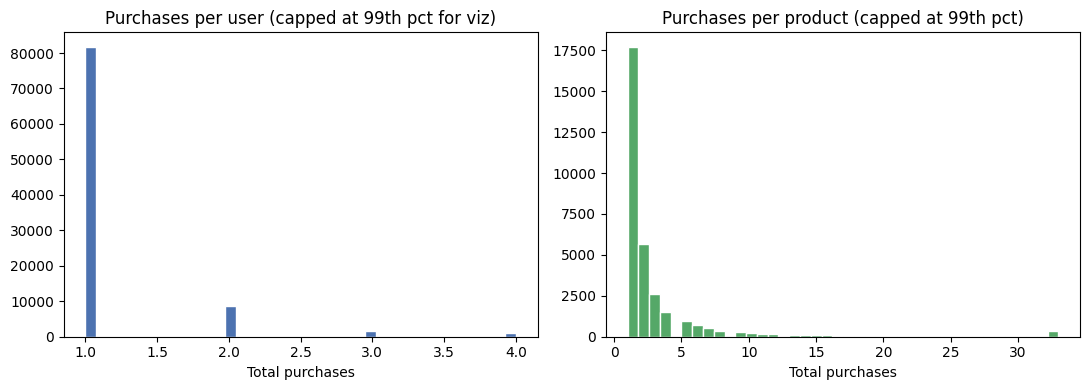

Users: 93358   Products: 32216   Edges: 99785


In [5]:
import json

import matplotlib.pyplot as plt
import pandas as pd

from recommender.cleaning import clean_olist, line_items_to_interaction_counts

cleaned = clean_olist(DATA_DIR)
display(cleaned.profile)

inter = line_items_to_interaction_counts(cleaned.line_items)
uc = inter.groupby("customer_unique_id")["purchase_count"].sum().sort_values(ascending=False)
pc = inter.groupby("product_id")["purchase_count"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(uc.clip(upper=uc.quantile(0.99)), bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_title("Purchases per user (capped at 99th pct for viz)")
axes[0].set_xlabel("Total purchases")
axes[1].hist(pc.clip(upper=pc.quantile(0.99)), bins=40, color="#55A868", edgecolor="white")
axes[1].set_title("Purchases per product (capped at 99th pct)")
axes[1].set_xlabel("Total purchases")
plt.tight_layout()
plt.show()

print("Users:", inter["customer_unique_id"].nunique(), "  Products:", inter["product_id"].nunique(), "  Edges:", len(inter))

## 5) Train + temporal hold-out eval → write artifacts
Eval model fits **train-time** slice only; **saved** `model.joblib` is fit on **full** interactions.

In [6]:
from recommender.pipeline import run_pipeline

run_pipeline(
    data_dir=DATA_DIR,
    artifacts_dir=ARTIFACTS_DIR,
    n_components=CONFIG["n_components"],
    min_user_purchases=CONFIG["min_user_purchases"],
    min_product_purchases=CONFIG["min_product_purchases"],
    test_fraction=CONFIG["test_fraction"],
    eval_k=CONFIG["eval_k"],
    eval_max_users=CONFIG["eval_max_users"],
    skip_eval=CONFIG["skip_eval"],
)

for name in ["model.joblib", "metrics.json", "data_profile.json", "model_meta.json"]:
    p = ARTIFACTS_DIR / name
    print(f"{'OK' if p.exists() else 'MISSING':6}  {p.name}")

{
  "artifacts": "C:\\Users\\ambro\\healthcare-system\\services\\marketplace-recommendation-ml\\artifacts",
  "meta": {
    "n_users": 1503,
    "n_products": 882,
    "n_components": 32,
    "data_dir": "C:\\Users\\ambro\\healthcare-system\\services\\marketplace-recommendation-ml\\data\\olist",
    "model_path": "C:\\Users\\ambro\\healthcare-system\\services\\marketplace-recommendation-ml\\artifacts\\model.joblib"
  },
  "evaluation": {
    "hit_rate_at_k": 0.06818181818181818,
    "mean_rank_percentile": 0.3822876896089154,
    "n_evaluated": 44,
    "n_skipped_cold_user": 222,
    "test_edges": 303,
    "note": "SVD fit on train-time matrix only; final saved model is fit on full interactions."
  }
}
OK      model.joblib
OK      metrics.json
OK      data_profile.json
OK      model_meta.json


## 6) Metrics table + chart

,hit_rate_at_k,mean_rank_percentile,n_evaluated,test_edges
0,0.068182,0.382288,44,303


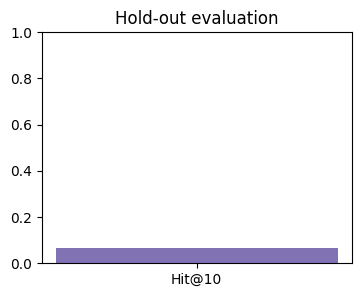

In [7]:
import json

import pandas as pd

metrics = json.loads((ARTIFACTS_DIR / "metrics.json").read_text(encoding="utf-8"))
ev = metrics.get("evaluation", {})
if isinstance(ev, dict) and "hit_rate_at_k" in ev:
    display(pd.DataFrame([ev])[["hit_rate_at_k", "mean_rank_percentile", "n_evaluated", "test_edges"]])
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.bar([f"Hit@{CONFIG['eval_k']}"], [ev["hit_rate_at_k"]], color="#8172B3")
    ax.set_ylim(0, 1)
    ax.set_title("Hold-out evaluation")
    plt.show()
else:
    display(ev)

## 7) Load model + recommendation table

In [8]:
import joblib
import pandas as pd

from recommender.train_matrix import StoredPurchaseModel

model: StoredPurchaseModel = joblib.load(ARTIFACTS_DIR / "model.joblib")
cust = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
SAMPLE_USER = str(cust["customer_unique_id"].iloc[0])

rows = []
for pid, score in model.recommend(SAMPLE_USER, top_k=12, mask_purchased=True):
    rows.append(
        {
            "product_id": pid,
            "score": score,
            "category": model.product_categories.get(pid, ""),
        }
    )
rec_df = pd.DataFrame(rows)
print("User:", SAMPLE_USER)
display(rec_df)

User: 861eff4711a542e4b93843c6dd7febb0


,product_id,score,category
0,422879e10f46682990de24d770e7f83d,1.000000,ferramentas_jardim
1,b532349fe46b38fbc7bb3914c1bdae07,0.500000,moveis_decoracao
2,368c6c730842d78016ad823897a372db,0.333333,ferramentas_jardim
3,389d119b48cf3043d311335e499d9c6b,0.250000,ferramentas_jardim
4,53759a2ecddad2bb87a079a1f1519f73,0.200000,ferramentas_jardim
5,a62e25e09e05e6faf31d90c6ec1aa3d1,0.166667,relogios_presentes
6,d5991653e037ccb7af6ed7d94246b249,0.142857,informatica_acessorios
7,eb8c629f70275fd1c4f809116cce1efc,0.125000,moveis_decoracao
8,9ecadb84c81da840dbf3564378b586e9,0.111111,moveis_decoracao
9,aca2eb7d00ea1a7b8ebd4e68314663af,0.100000,moveis_decoracao


## 8) Serve the model (terminal)
```bash
cd services/marketplace-recommendation-ml
uvicorn serve:app --host 127.0.0.1 --port 8095
```

`POST http://127.0.0.1:8095/v1/recommend` with body:
```json
{"customer_unique_id": "<from customers CSV>", "top_k": 10, "mask_purchased": true}
```